In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
!pip install plotly
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable


In [2]:
df = pd.read_csv("C:/Users/Jagdish singh/projects/datasets/student-por.csv")

In [3]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
df.columns
#df.info()
#df.size
df.isnull().value_counts().sum()

np.int64(649)

In [6]:
df.info()
df.dtypes.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

array([dtype('O'), dtype('int64')], dtype=object)

In [7]:
df.isnull().sum()
#no null values

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [15]:
cat_col_df=df.select_dtypes(include='object')
cat_col_df

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,no,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,no,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,no,no,yes,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,R,GT3,T,services,other,course,mother,no,no,no,yes,no,yes,yes,no
645,MS,F,U,LE3,T,teacher,services,course,mother,no,yes,no,no,yes,yes,yes,no
646,MS,F,U,GT3,T,other,other,course,mother,no,no,no,yes,yes,yes,no,no
647,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no


In [14]:
num_col_df=df.select_dtypes(exclude='object')
num_col_df

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,4,0,11,11
1,17,1,1,1,2,0,5,3,3,1,1,3,2,9,11,11
2,15,1,1,1,2,0,4,3,2,2,3,3,6,12,13,12
3,15,4,2,1,3,0,3,2,2,1,1,5,0,14,14,14
4,16,3,3,1,2,0,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,19,2,3,1,3,1,5,4,2,1,2,5,4,10,11,10
645,18,3,1,1,2,0,4,3,4,1,1,1,4,15,15,16
646,18,1,1,2,2,0,1,1,1,1,1,5,6,11,12,9
647,17,3,1,2,1,0,2,4,5,3,4,2,6,10,10,10


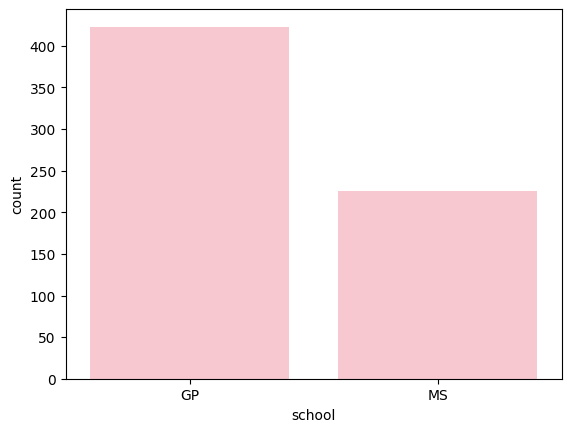

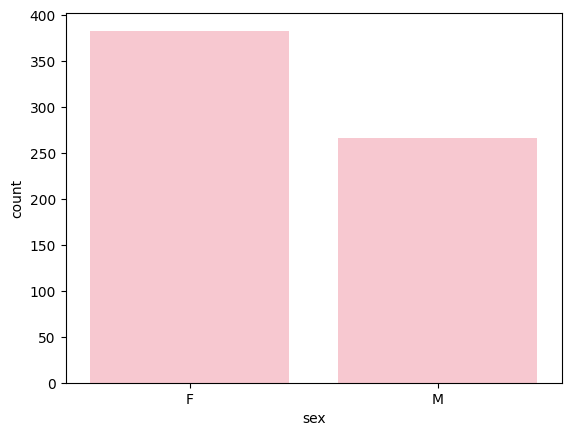

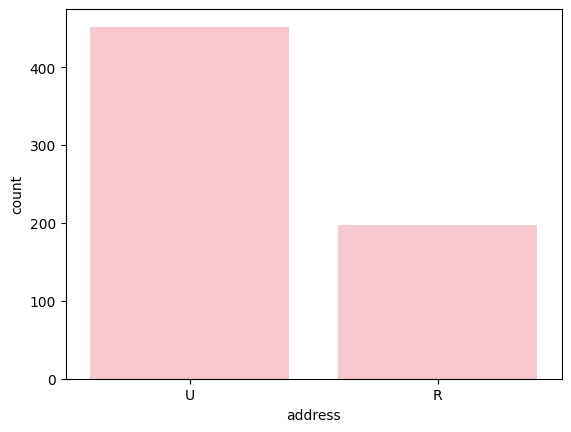

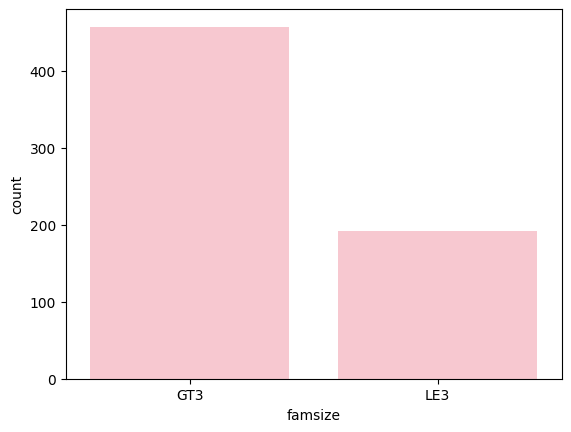

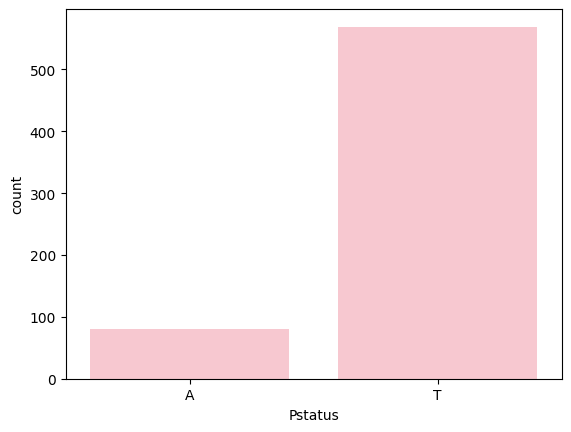

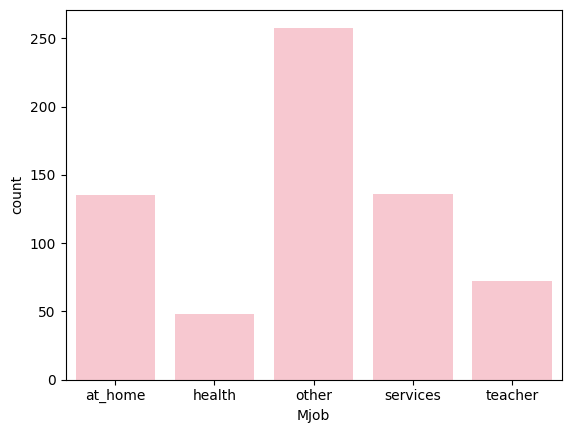

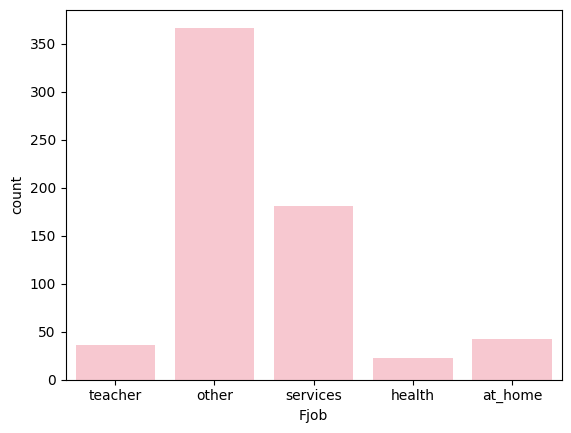

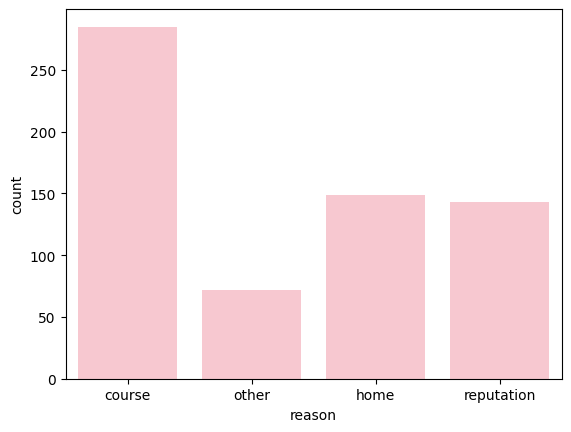

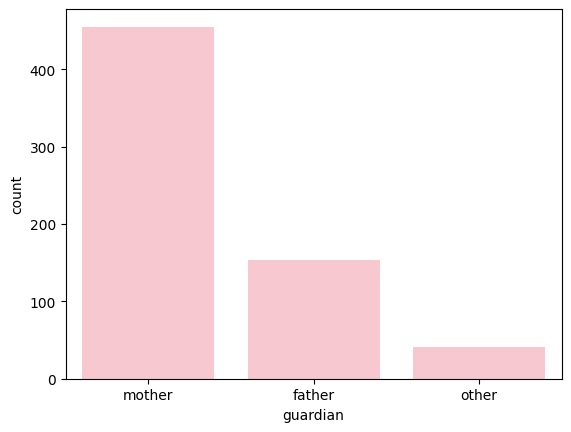

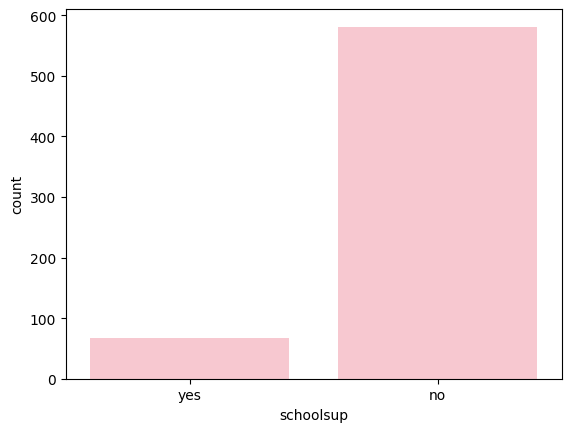

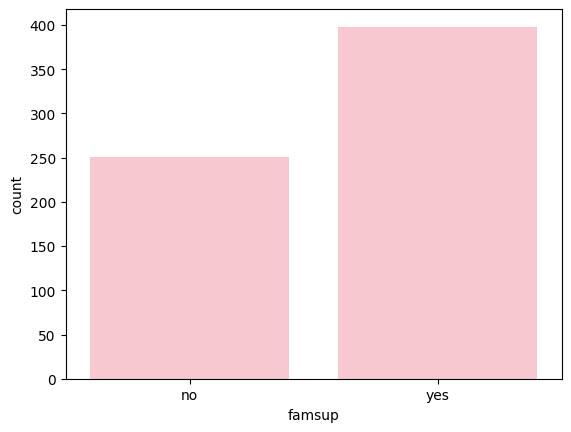

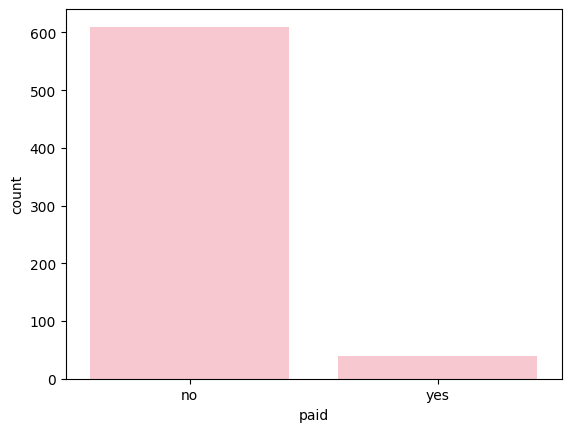

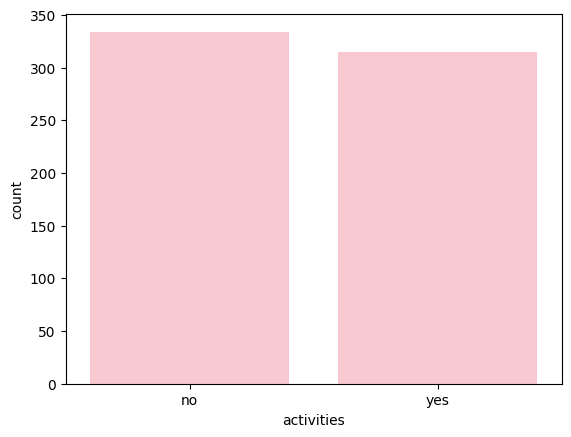

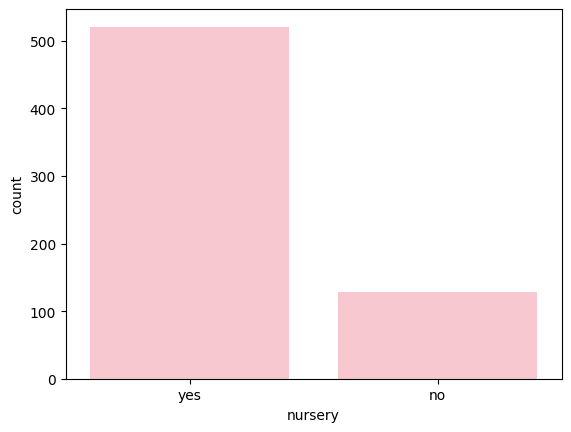

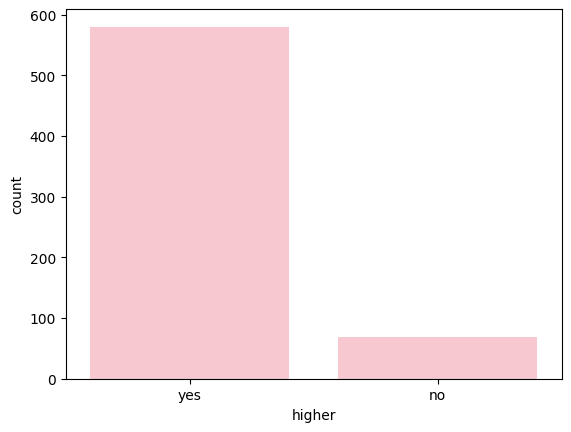

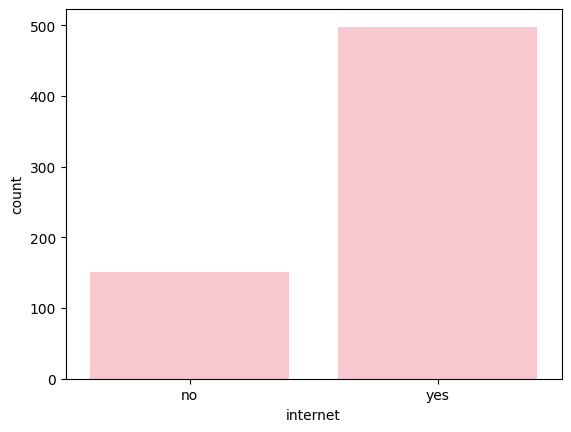

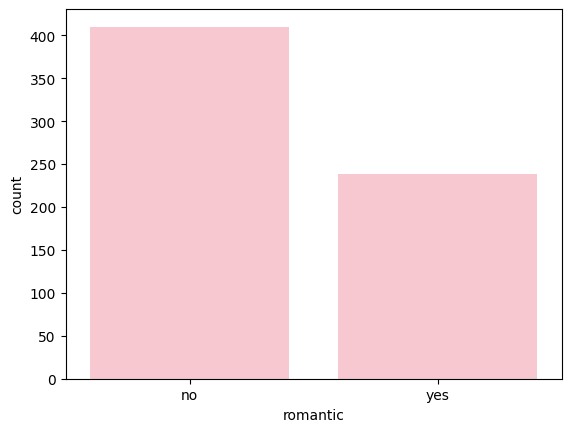

In [13]:
for i in cat_col_df:
    sns.countplot(x=df[i],data=df,color='pink')
    plt.show()

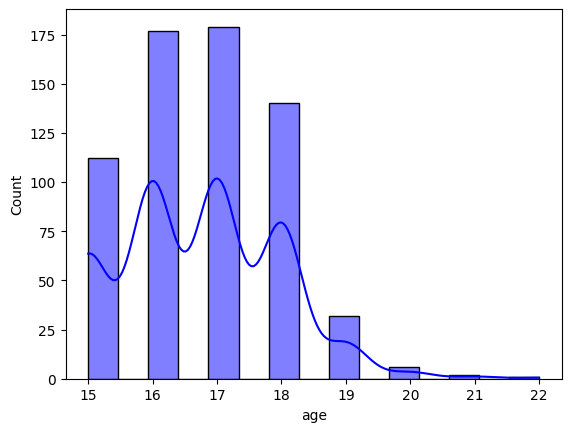

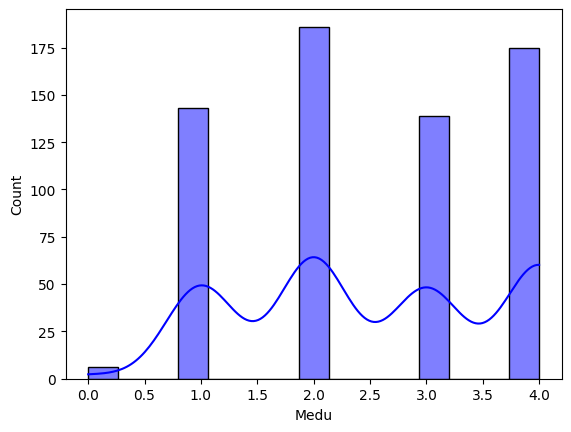

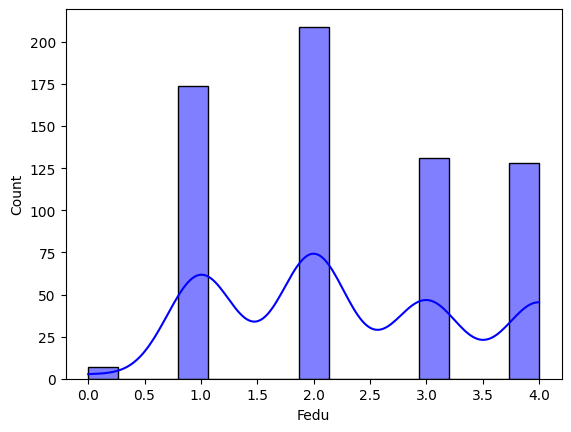

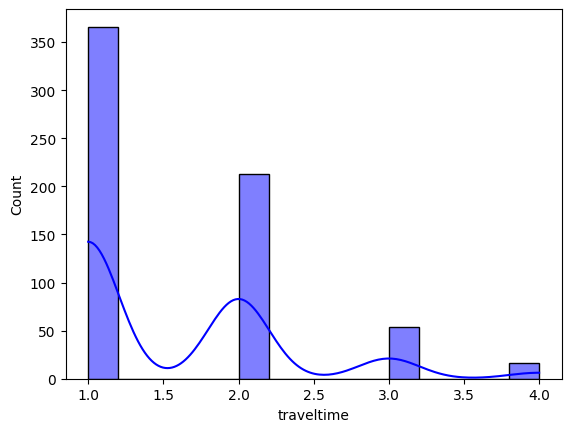

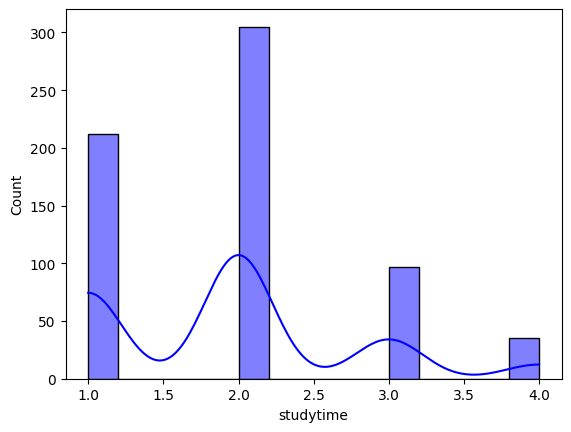

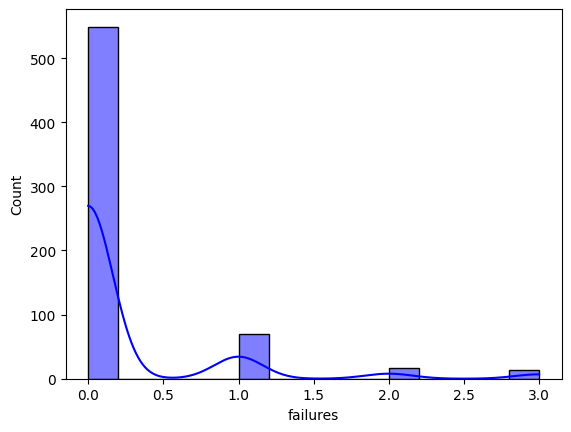

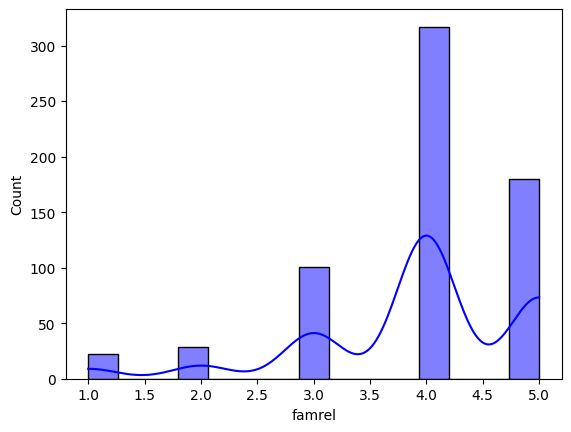

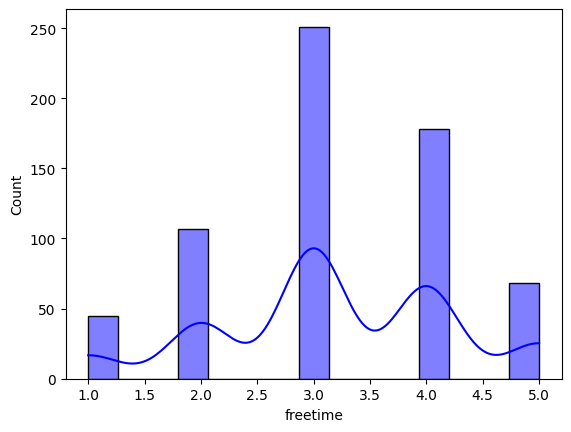

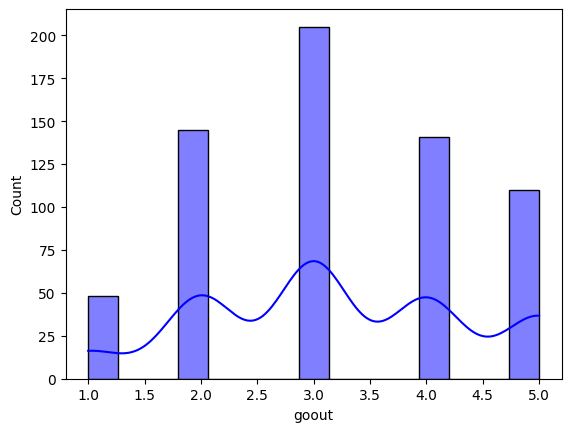

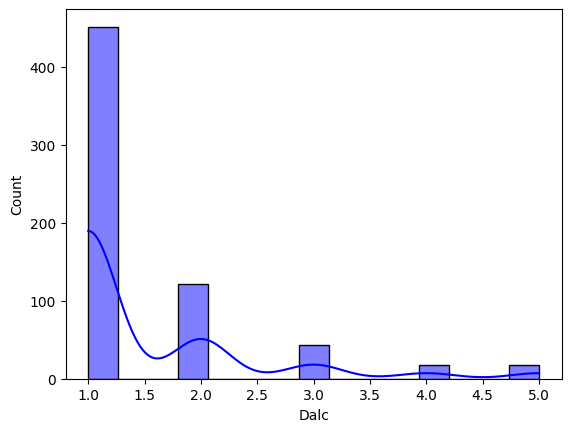

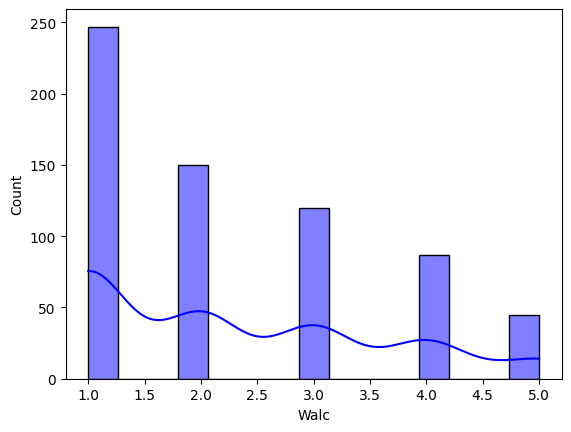

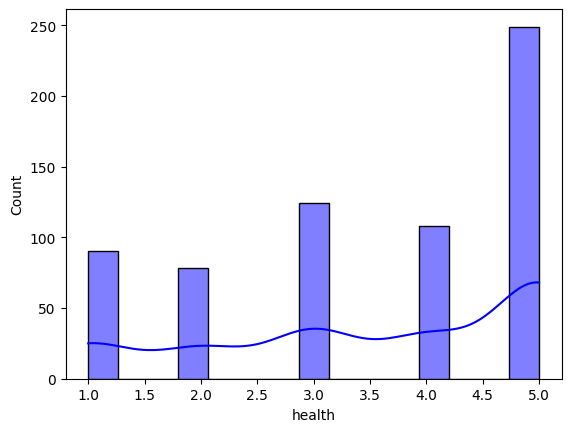

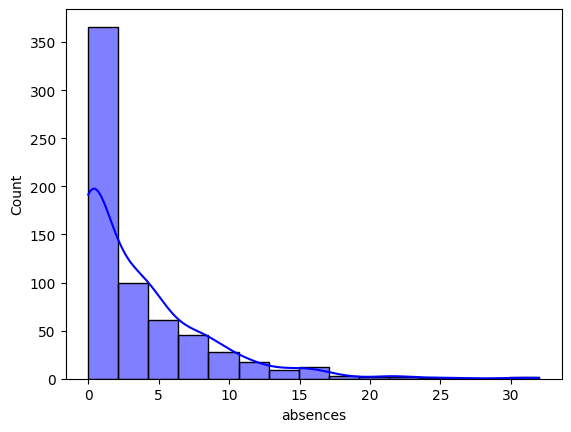

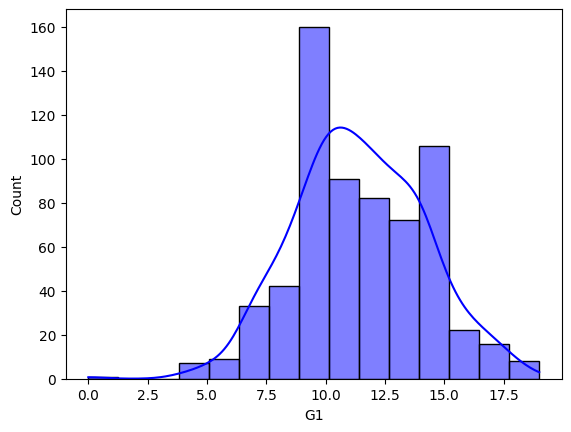

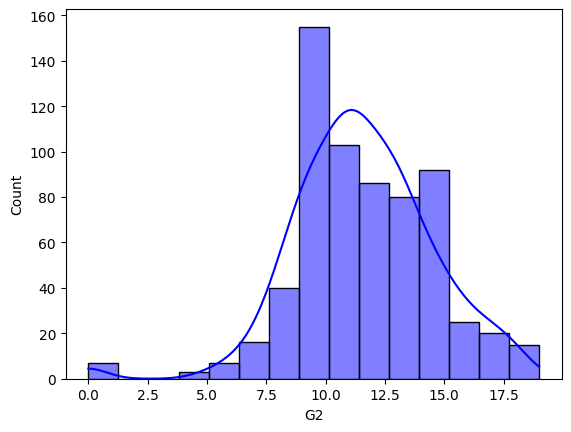

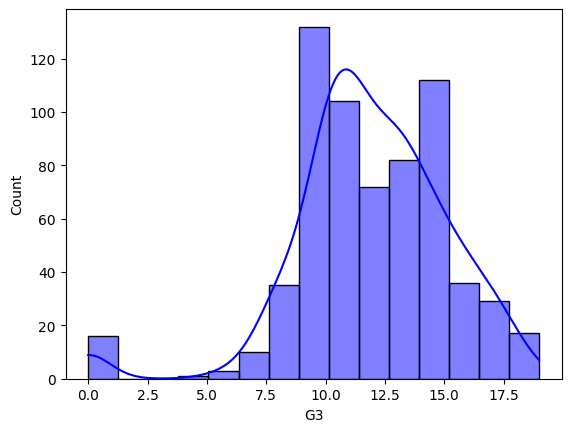

In [16]:
for i in num_col_df:
    sns.histplot(x=df[i],data=df,kde=True,color='blue',bins=15)
    plt.show()
    

In [11]:
cat_col_df.columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

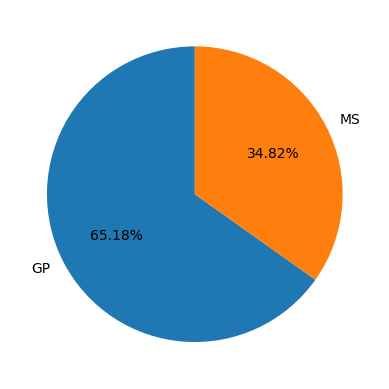

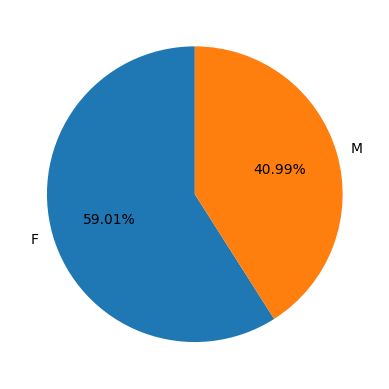

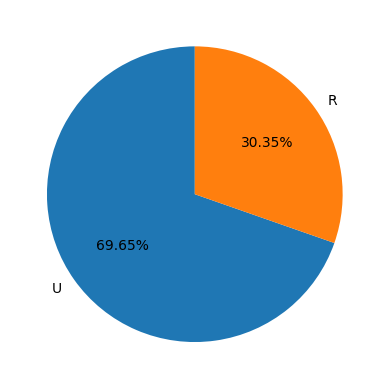

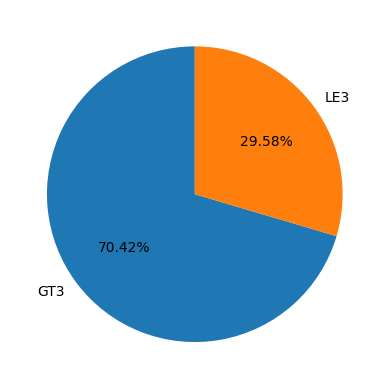

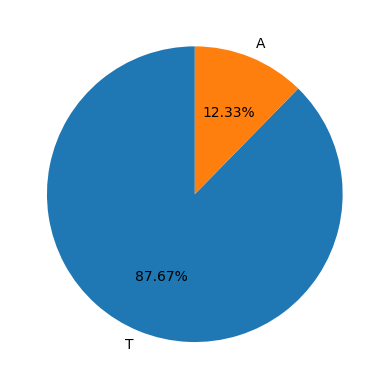

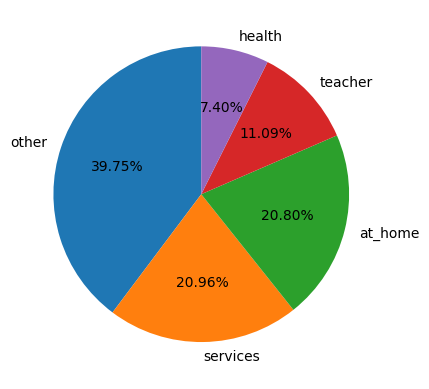

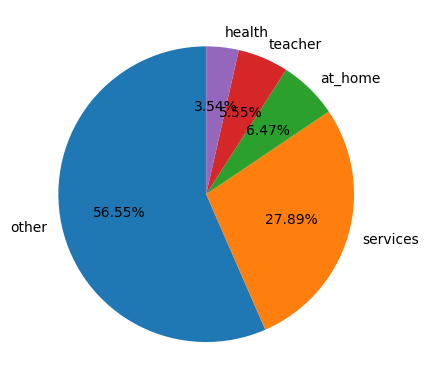

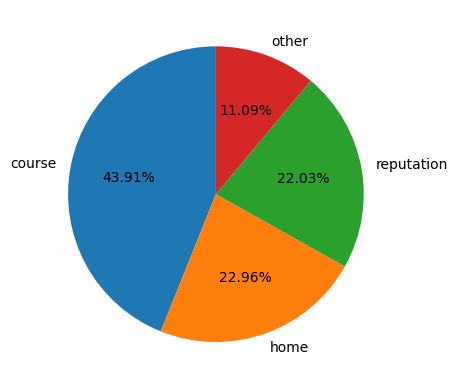

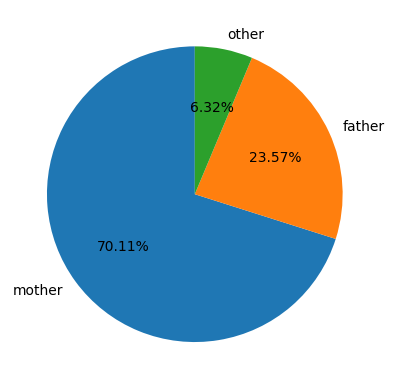

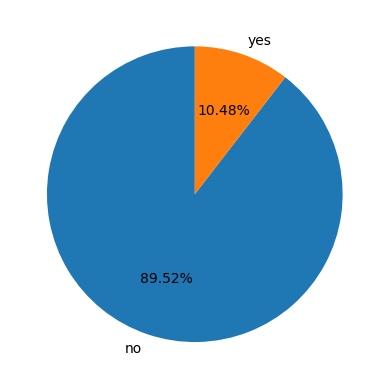

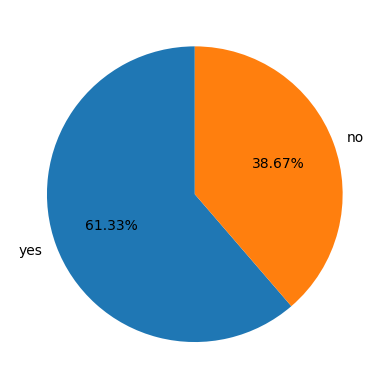

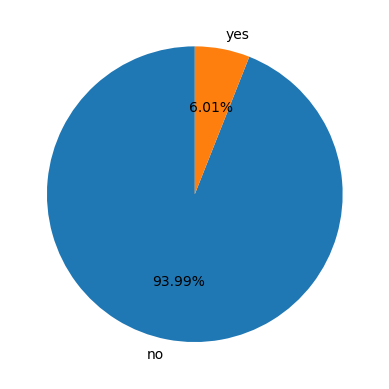

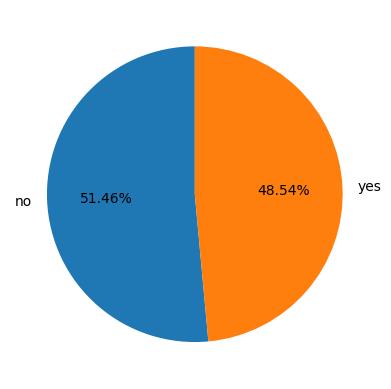

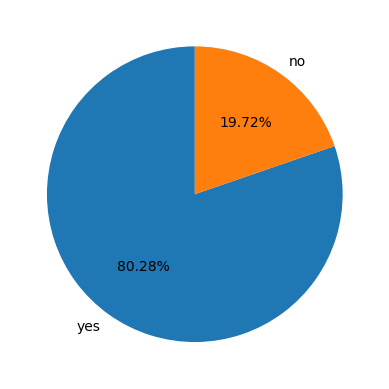

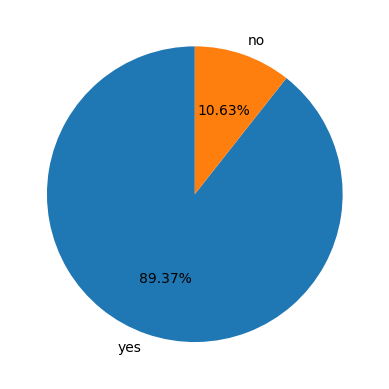

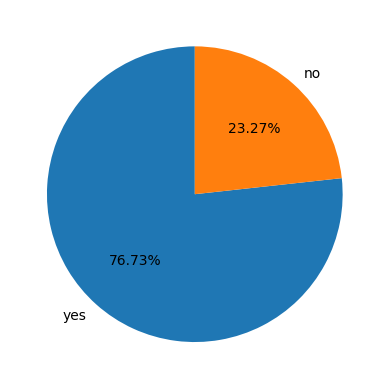

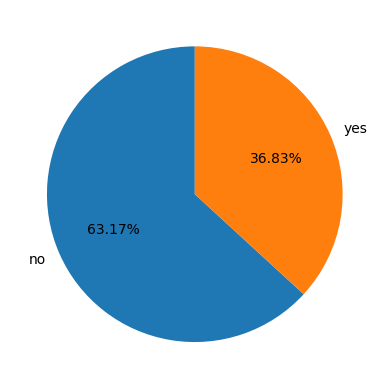

In [9]:
for i in cat_col_df:
    plt.pie(df[i].value_counts(),autopct='%1.2f%%',startangle=90,labels=df[i].value_counts().index)
    plt.show()

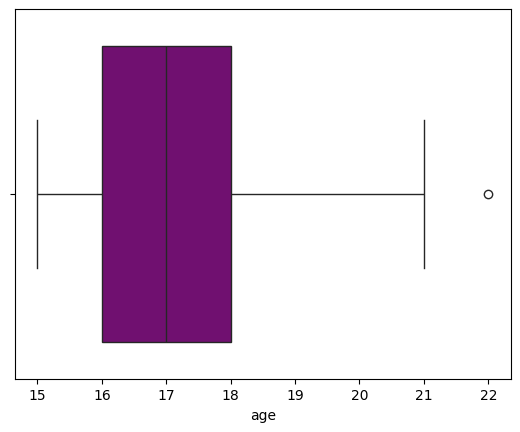

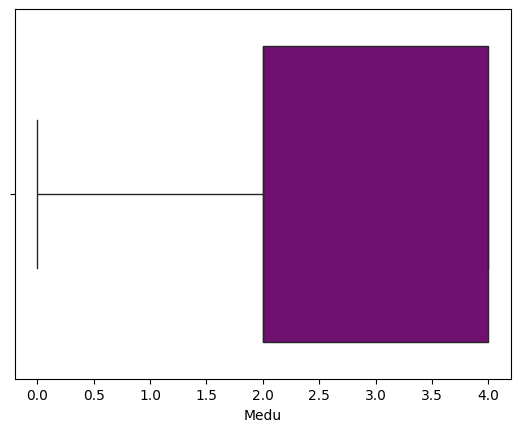

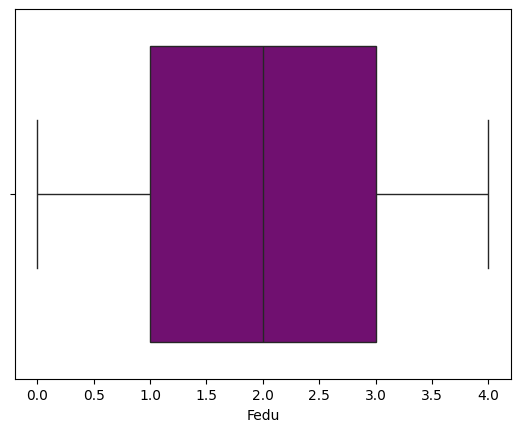

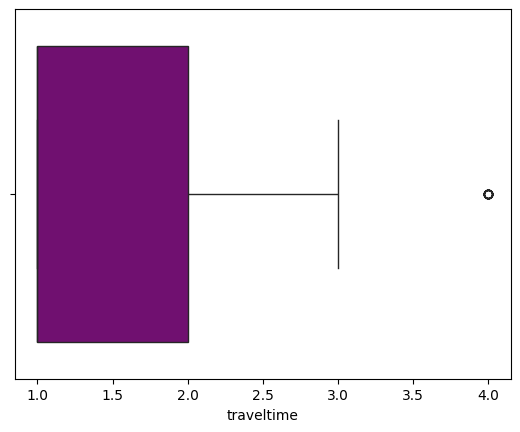

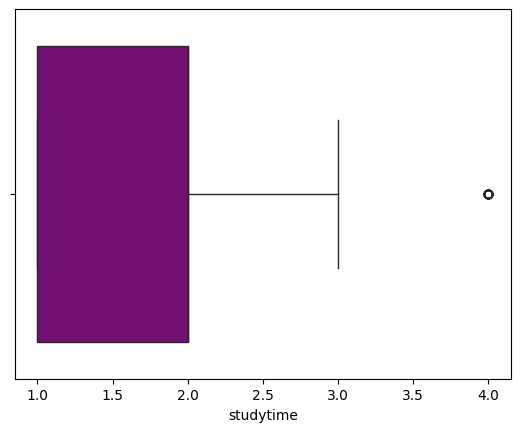

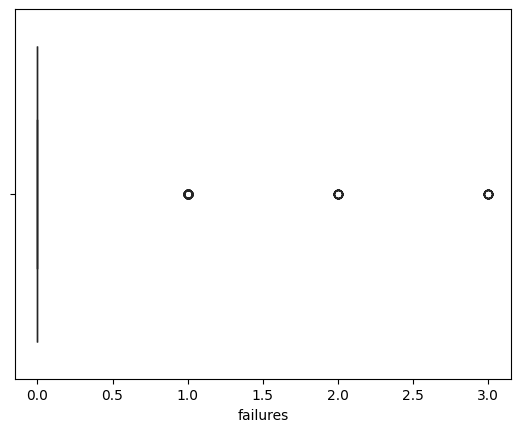

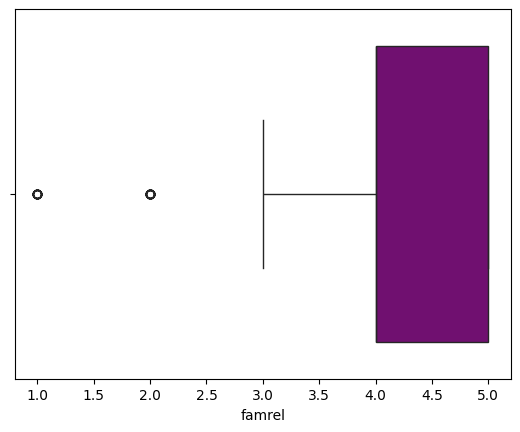

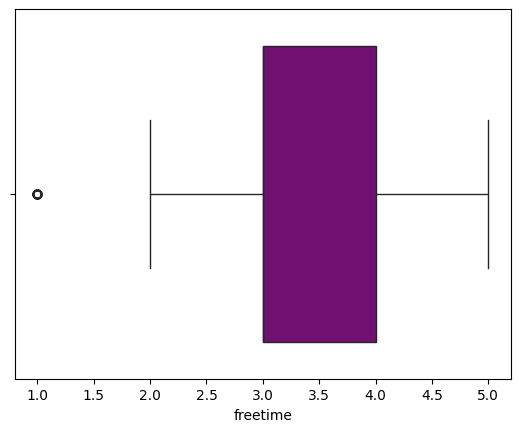

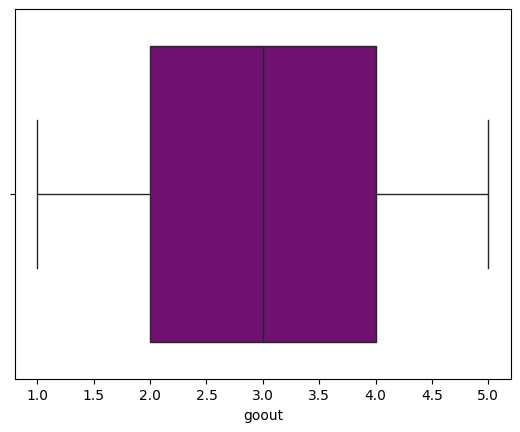

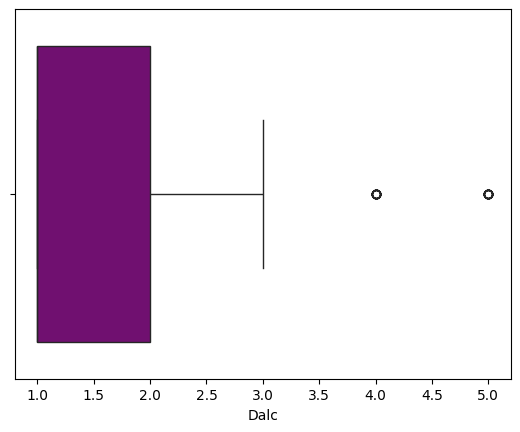

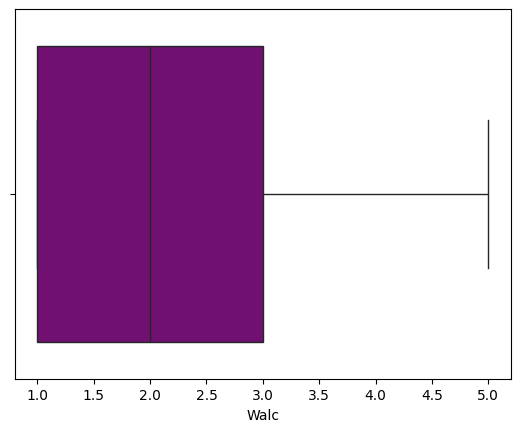

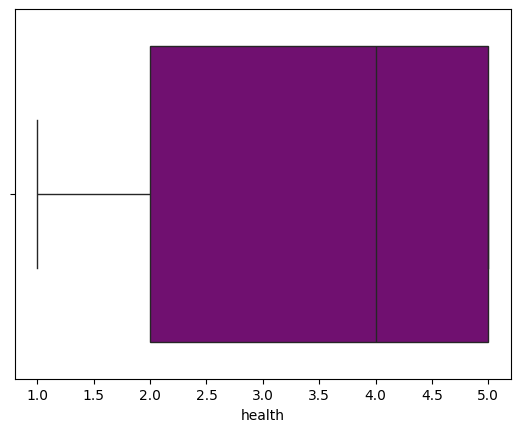

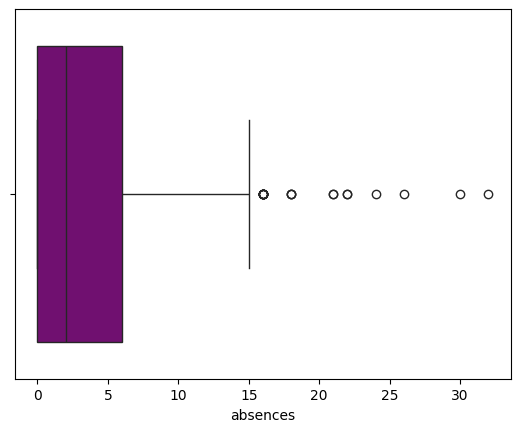

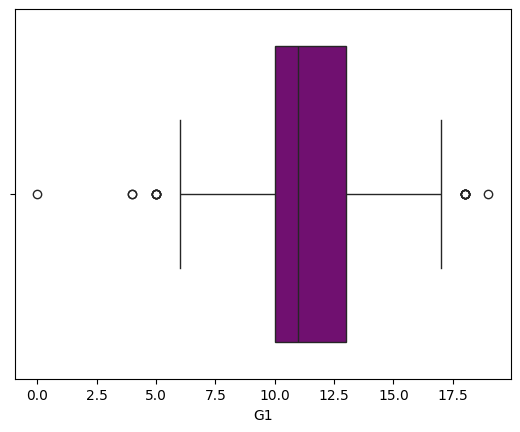

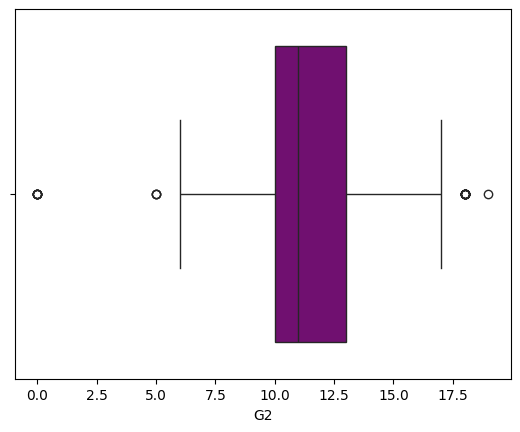

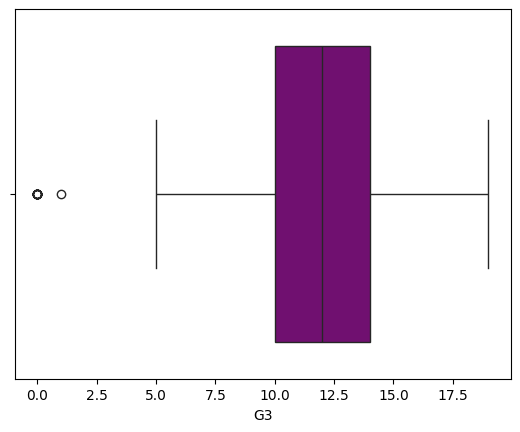

In [18]:
for i in num_col_df:
    sns.boxplot(x=i, data=df,color='purple')
    plt.show()

In [ ]:
# bivaraite analysis

In [21]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [22]:
df.Fedu

0      4
1      1
2      1
3      2
4      3
      ..
644    3
645    1
646    1
647    1
648    2
Name: Fedu, Length: 649, dtype: int64

In [23]:
df.Medu

0      4
1      1
2      1
3      4
4      3
      ..
644    2
645    3
646    1
647    3
648    3
Name: Medu, Length: 649, dtype: int64

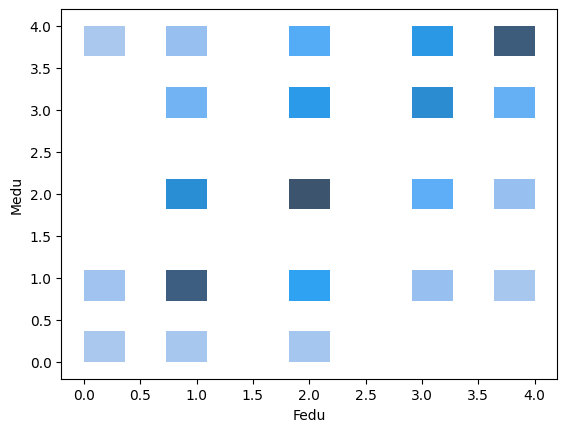

In [24]:
sns.histplot(x='Fedu',y='Medu',data=df)
plt.show()

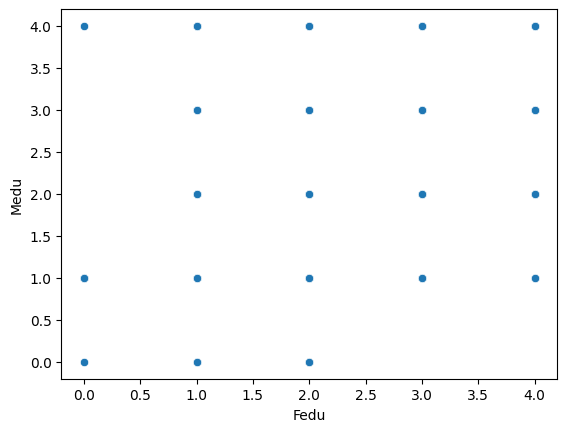

In [26]:
sns.scatterplot(x='Fedu',y='Medu',data=df)
plt.show()

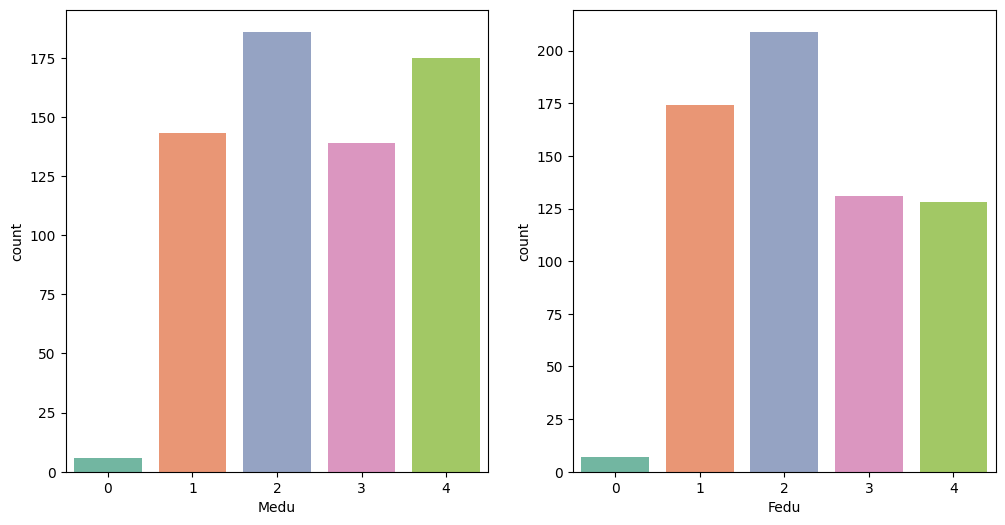

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x='Medu',data=df,palette='Set2')
plt.subplot(1,2,2)
sns.countplot(x='Fedu',data=df,palette='Set2')
plt.show()


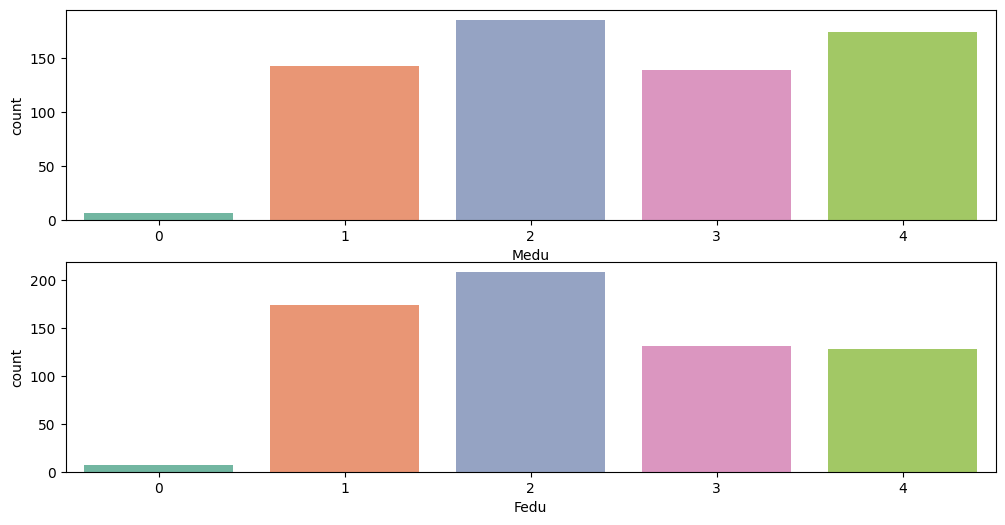

In [28]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
sns.countplot(x='Medu',data=df,palette='Set2')
plt.subplot(2,1,2)
sns.countplot(x='Fedu',data=df,palette='Set2')
plt.show()

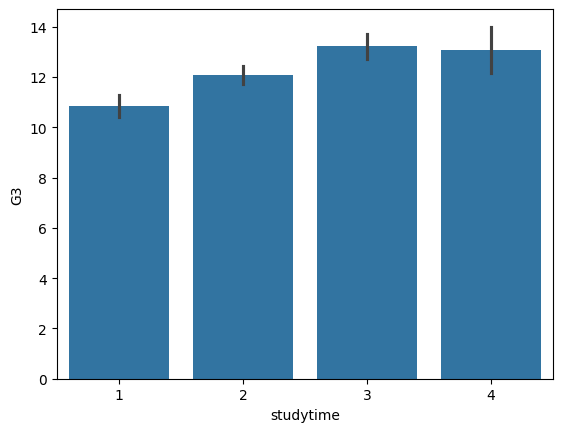

In [30]:
df.G3
df.studytime
sns.barplot(y='G3',x='studytime',data=df)
plt.show()

In [ ]:
#genrate isnights from graph

In [31]:
cat_col_df.columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

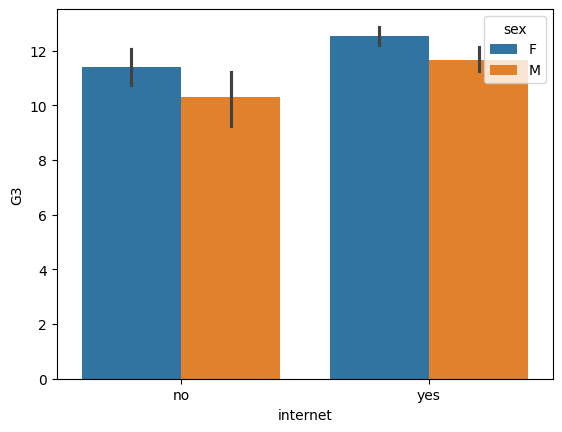

In [71]:
sns.barplot(x=df['internet'], y='G3',data=df,hue='sex')
plt.show()

In [ ]:
#multivaraite analysis

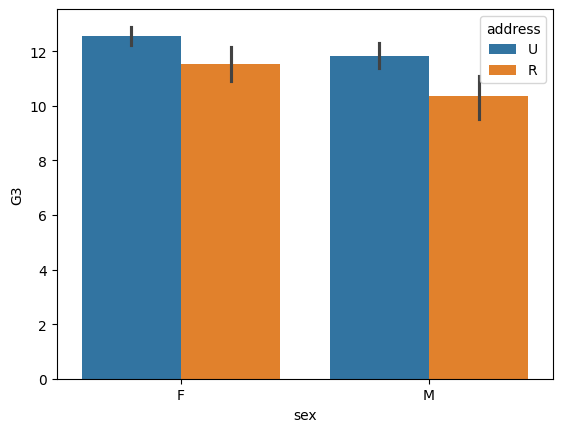

In [73]:
sns.barplot(x=df['sex'], y='G3',data=df,hue='address')
plt.show()

In [32]:
num_col_df.columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

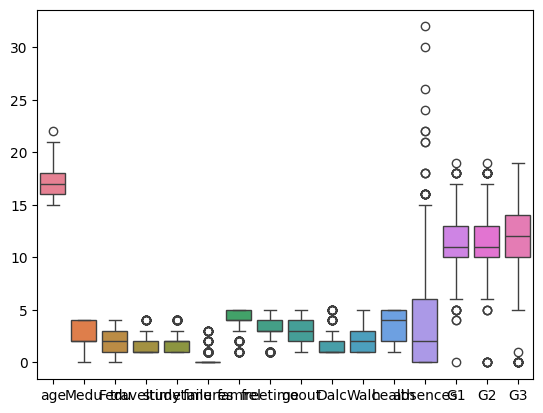

In [ ]:
sns.boxplot(data=num_col_df)
plt.show()

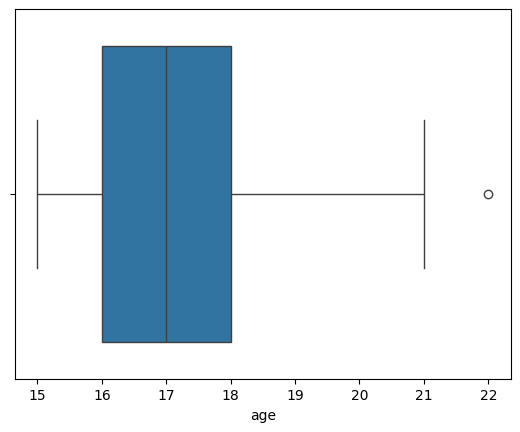

In [39]:
sns.boxplot(x=df.age)
plt.show()

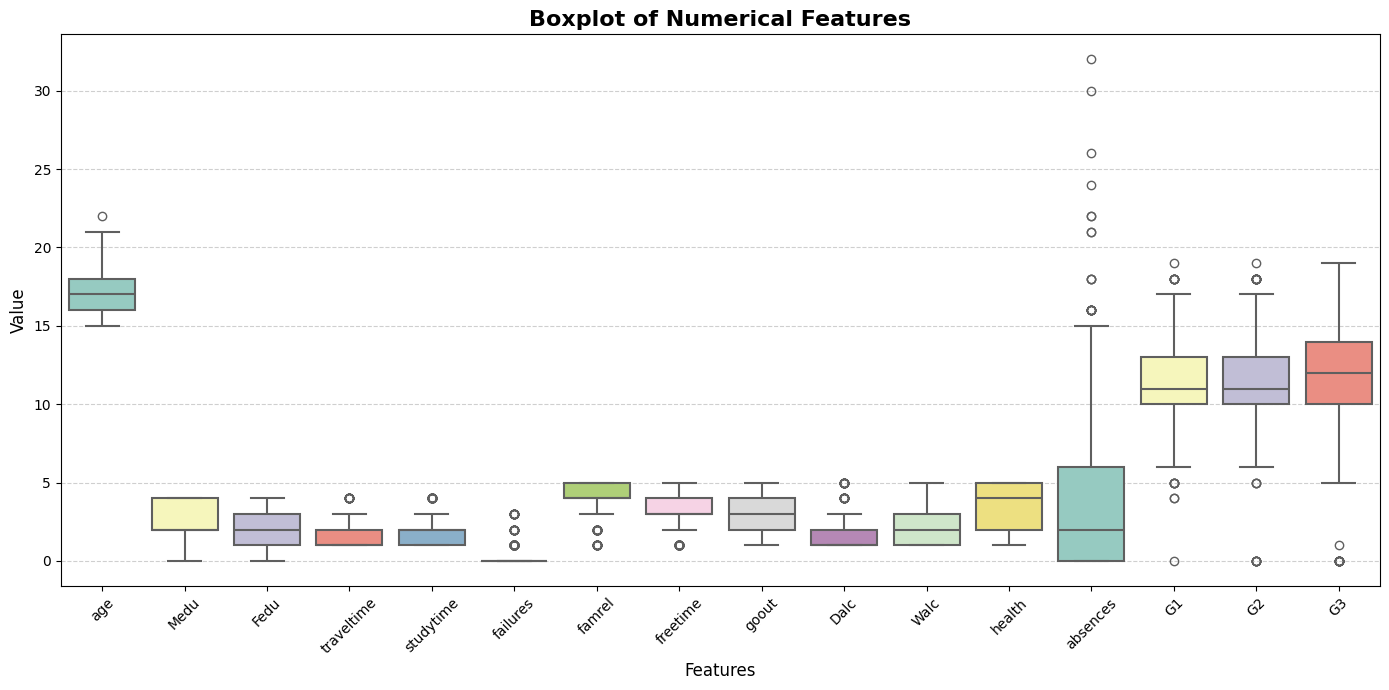

In [40]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=num_col_df,
    palette="Set3",
    linewidth=1.5
)

plt.title("Boxplot of Numerical Features", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=12)
plt.ylabel("Value", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


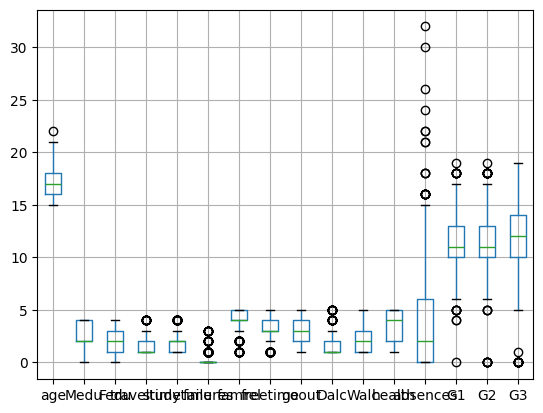

In [84]:
num_col_df.boxplot()
plt.show()

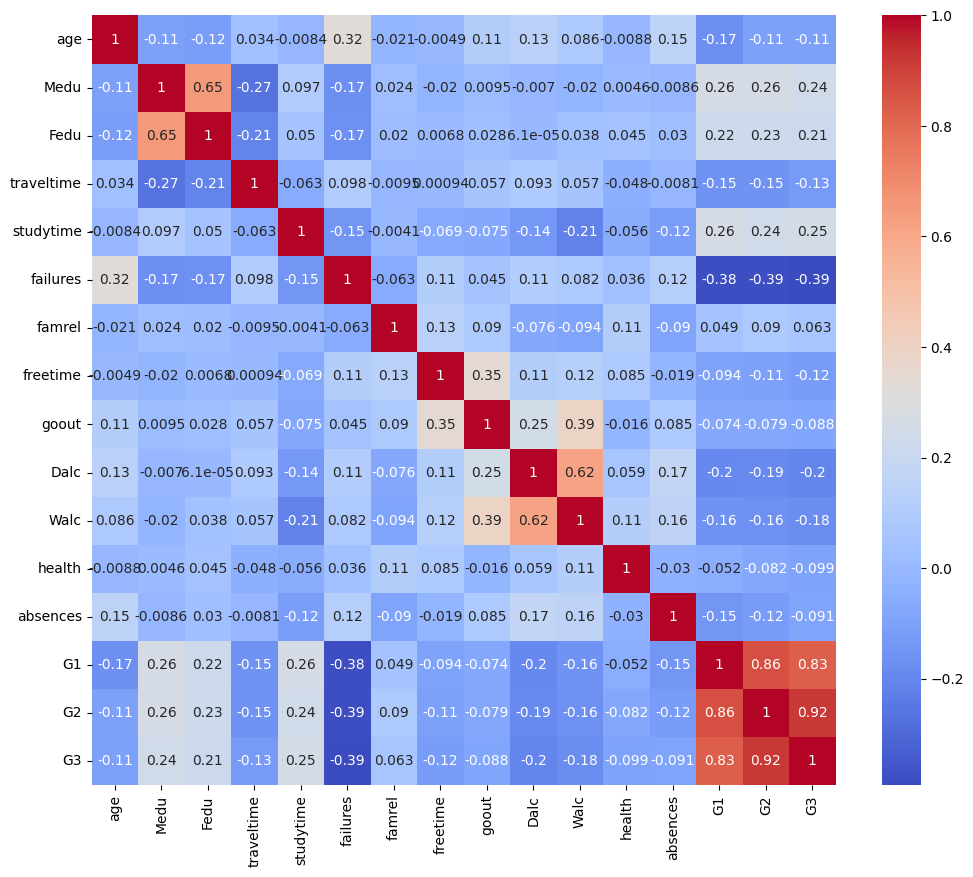

In [87]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [41]:
students_grades_df=df.copy()
newdf=df.copy()
students_grades_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [42]:

students_grades_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [43]:
students_grades_df = students_grades_df.drop(['G1', 'G2', 'G3'], axis=1)
students_grades_df.columns


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences'],
      dtype='object')

In [ ]:
def detect_outliers(columns):
    outlier_indices = []
    for column in columns:
        Q1=students_grades_df[column].quantile(0.25)
        Q3=students_grades_df[column].quantile(0.75)
        IQR = Q3-Q1
        
        #mask is a boolean condition
        mask = (students_grades_df[column] >= (Q1-1.5*IQR)) & (students_grades_df[column] <= (Q3+1.5*IQR))
        mask = mask.to_numpy() #bool to numpy array
        
        #find the indices of values that do not satisfy the mask condition>> that will be outlier
        false_indices = np.argwhere(~mask)
        outlier_indices.append(false_indices)
    return np.unique(np.concatenate(outlier_indices).ravel())

#np.concatenate(outlier_indices)>> combine all the outlier index arrays into a single array
#so each column will have one array
#.ravel>> flattens the multi-dimensional array into 1 d array
      

In [133]:
import numpy as np

def detecting(newdf):
    outlier_index = []

    for col in newdf.columns:
        q1 = newdf[col].quantile(0.25)
        q3 = newdf[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # directly selecting outlier values
        false_index = newdf[
            (newdf[col] < lower_bound) | (newdf[col] > upper_bound)
        ].index

        outlier_index.append(false_index)

    return np.unique(np.concatenate(outlier_index))


In [ ]:
sns.boxplot(x=df.age)
plt.show()

In [ ]:
sns.boxplot(x=df.absences)
plt.show()

In [105]:
num_cols = ["age", "absences"]
detect_outliers(num_cols)

array([ 40, 103, 150, 155, 161, 197, 206, 211, 212, 217, 230, 253, 254,
       256, 263, 279, 311, 325, 326, 397, 405, 413])

In [68]:
num_cols = ['age', 'absences']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df.loc[
        (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR),
        col
    ].reset_index()

    print(f"{col} outliers:")
    print(outliers)
    print()


age outliers:
   index  age
0    279   22

absences outliers:
    index  absences
0      40        16
1     103        16
2     150        24
3     155        22
4     161        16
5     197        32
6     206        16
7     211        16
8     212        30
9     217        21
10    230        16
11    253        18
12    254        16
13    256        26
14    263        16
15    311        16
16    325        22
17    326        18
18    397        18
19    405        16
20    413        21



In [53]:
df.shape

(649, 33)

In [67]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

outliers = df['age'][(df['age'] < Q1 - 1.5*IQR) | (df['age'] > Q3 + 1.5*IQR)].reset_index()
outliers

,index,age
0,279,22


In [106]:
students_grades_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences'],
      dtype='object')

In [114]:
#considering absences as the target variable
X, y = students_grades_df.iloc[:, :-1], students_grades_df.iloc[:, -1]

In [117]:
X

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,yes,no,no,4,3,4,1,1,3
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,yes,yes,no,5,3,3,1,1,3
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,yes,no,4,3,2,2,3,3
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,yes,3,2,2,1,1,5
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,yes,no,no,4,3,2,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,no,yes,yes,no,5,4,2,1,2,5
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,yes,no,4,3,4,1,1,1
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,yes,no,no,1,1,1,1,1,5
647,MS,M,17,U,LE3,T,3,1,services,services,...,no,yes,yes,no,2,4,5,3,4,2


In [109]:
y

0      4
1      2
2      6
3      0
4      0
      ..
644    4
645    4
646    6
647    6
648    4
Name: absences, Length: 649, dtype: int64

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=1)

In [118]:
X_train.shape

(486, 29)

In [119]:
X_test.shape

(163, 29)

In [61]:
def outlier_values_each_column(df):
    result = {}

    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        result[col] = df[col].loc[
            (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        ]

    return result


In [ ]:
outliers = outlier_values_each_column(df['age'])
outliers

In [56]:
def outliers_one_column(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    return series[(series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)]


In [57]:
import pandas as pd
import numpy as np

def get_outliers(df, columns, method='IQR'):
    """
    Detects outliers in given columns of a DataFrame.

    Parameters:
    df : pandas.DataFrame
    columns : list of column names
    method : 'IQR' or 'Z' for outlier detection

    Returns:
    dict : {column_name: Series of outlier values}
    """
    outlier_dict = {}

    for col in columns:
        if method == 'IQR':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            outliers = df[col][(df[col] < lower) | (df[col] > upper)]

        elif method == 'Z':
            mean = df[col].mean()
            std = df[col].std()
            z = (df[col] - mean) / std
            outliers = df[col][np.abs(z) > 3]

        else:
            raise ValueError("Method must be 'IQR' or 'Z'")

        outlier_dict[col] = outliers

    return outlier_dict
